# Demand Forecast — Hourly H3 Zone Quotes

**Goal:** Forecast hourly quote demand per H3 zone for April 1–7, 2026, and translate demand into estimated trip counts using historical conversion rates.

**Main Approach** 
  1. Predict raw number of quotes to be creates for each of the zones defined.
  2. Multiply raw numbers of quotes to be created by average historic conversion rate for the same hour on the same weekday for each zone..
  3. Produce this predictions for: lower bound of of prediction, prediction itself and upper bound.

**Zones:**  14 stable-conversion H3 hexagons in London, defined in h3_zone_assignment.ipynb

**Content**
  - Ponits #2-#4 model's fit, based on MAPE (the best choice for volume-diverse prediciton's comaprisons)
  - Point #5 more detailed models fit: grid search for each of the zones, choice is based on average MAPE per zone and credible interval coverage (how frequently octual values fit into estimated credible intervals).
    - In a result the chosen approach is prophet time series forecast with features: 1 week lag and 2 week lag of quotes created, weather features of temperature_m2 and visibility, and fitted with grid search for each zone individually changepoint_prior_scale, seasonality_prior_scale. 
    - For the week hourly predictions from 22nd to 28th March.
      - Median (among zones) Avg (per zone) MAPE: 33.5%
      - Median (among zones) Avg CI coverage (per zone) : 94.0%  (target 95%). 
  - Point #6 anlysis of seasonal componet fetched by prophet for one of the zones for the last week of march predictions, their visualisation.
  - Points #8-9 visualisation of results for 1-7 April hourly predictions.
  - Point #10 predictions saved

In [1]:
import sys
import importlib
import itertools
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import h3
from shapely.geometry import Polygon
from tqdm import tqdm

import src.forecasting
import src.forecasting_vis_helpers
importlib.reload(src.forecasting)
importlib.reload(src.forecasting_vis_helpers)

from src.forecasting import (
    prepare_zone_df,
    build_prophet_model,
    fit_and_forecast,
    build_baseline_ols,
    compute_mape,
    run_zone_forecast,
    run_zone_grid_search,
    compute_historical_conversion,
    apply_conversion_to_forecast,
    save_demand_forecast,
    DEMAND_FORECAST_COLS,
    WEATHER_REGRESSORS,
    _VARIANT_WEATHER,
)
from src.forecasting_vis_helpers import (
    make_zone_day_pivot,
    zone_day_heatmap,
    build_metric_pivots,
    plot_heatmap_pair,
    print_mape_cov_summary,
    h3_ids_to_geodataframe,
    plot_h3_demand_maps,
)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR       = Path("../data/processed")
QUOTES_WEATHER = DATA_DIR / "quotes_weather_h3.parquet"
FORECAST_PATH  = DATA_DIR / "weather_forecast_apr2026.parquet"
OUT_PATH       = DATA_DIR / "demand_forecast_apr2026.parquet"

# ── Time boundaries ───────────────────────────────────────────────────────────
MARCH_START = pd.Timestamp("2026-03-01 00:00:00", tz="UTC")
MARCH_END   = pd.Timestamp("2026-03-31 23:00:00", tz="UTC")
APR_START   = pd.Timestamp("2026-04-01 00:00:00", tz="UTC")
APR_END     = pd.Timestamp("2026-04-07 23:00:00", tz="UTC")

# ── Eval splits (tz-naive — matched to zone_df["ds"]) ─────────────────────────
HORIZONS = {
    14: {
        "train_end":  pd.Timestamp("2026-03-14 23:00:00"),
        "eval_start": pd.Timestamp("2026-03-15 00:00:00"),
        "eval_end":   pd.Timestamp("2026-03-21 23:00:00"),
        "label":      "H14 — train Mar 1–14, eval Mar 15–21",
    },
    21: {
        "train_end":  pd.Timestamp("2026-03-21 23:00:00"),
        "eval_start": pd.Timestamp("2026-03-22 00:00:00"),
        "eval_end":   pd.Timestamp("2026-03-28 23:00:00"),
        "label":      "H21 — train Mar 1–21, eval Mar 22–28",
    },
}

MODELS = [
    "ols",
    "prophet_base",
    "prophet_lags",
    "prophet_full_temp",
    "prophet_full_temp_vis",
    "prophet_full",
]
MODEL_LABELS = {
    "ols":                  "OLS baseline",
    "prophet_base":         "Prophet (base)",
    "prophet_lags":         "Prophet + lags",
    "prophet_full_temp":    "Prophet + lags + temp",
    "prophet_full_temp_vis":"Prophet + lags + temp + vis",
    "prophet_full":         "Prophet + lags + weather (all)",
}
MODEL_COLORS = {
    "ols":                  "#e6550d",
    "prophet_base":         "#3182bd",
    "prophet_lags":         "#31a354",
    "prophet_full_temp":    "#9ecae1",
    "prophet_full_temp_vis":"#2171b5",
    "prophet_full":         "#756bb1",
}

## 1. Load & inspect data

Load `quotes_weather_h3.parquet` (March 2026 actuals with hourly weather) and the April 2026 weather forecast.  
Filter the dataset to the 14 `cv_30` H3 zones used throughout; verify date range, zone count, and quote-count distribution.

In [2]:
df = pd.read_parquet(QUOTES_WEATHER)
print(f"Shape       : {df.shape}")
print(f"Date range  : {df['hour_bucket'].min()}  →  {df['hour_bucket'].max()}")
print(f"All zones   : {df['h3_zone'].nunique()}")

# Filter to high-conversion zones only
CV_FILTER = "cv_30"
ZONES     = sorted(df[df["cv_risk"] == CV_FILTER]["h3_zone"].unique())
print(f"cv_30 zones : {len(ZONES)}")

df_cv30 = df[df["cv_risk"] == CV_FILTER]
print(f"\nquote_count (cv_30): min={df_cv30['quote_count'].min()}  "
      f"mean={df_cv30['quote_count'].mean():.1f}  max={df_cv30['quote_count'].max()}")

# Weather forecast for April (used in production forecast for prophet_full)
weather_apr = pd.read_parquet(FORECAST_PATH)
weather_apr["ds"] = weather_apr["hour_bucket"].dt.tz_localize(None)
print(f"\nApril weather rows : {len(weather_apr)}")

FULL_INDEX = pd.date_range(MARCH_START, MARCH_END, freq="h", tz="UTC")
print(f"Full March index   : {len(FULL_INDEX)} hours")
df.head(3)

Shape       : (25214, 16)
Date range  : 2026-03-01 00:00:00+00:00  →  2026-03-31 23:00:00+00:00
All zones   : 35
cv_30 zones : 14

quote_count (cv_30): min=1  mean=32.4  max=315

April weather rows : 168
Full March index   : 744 hours


,h3_zone,hour_bucket,quote_count,trip_count,conversion_rate,hour_of_day,day_of_week,cv_risk,temperature_2m,apparent_temperature,rain,precipitation,precipitation_probability,wind_speed_10m,cloud_cover,visibility
0,87194ad06ffffff,2026-03-01 00:00:00+00:00,12,6,0.500000,0,6,cv_50,7.8955,5.146195,0.0,0.0,20.0,9.000000,95.0,25860.0
1,87194ad06ffffff,2026-03-01 01:00:00+00:00,16,2,0.125000,1,6,cv_50,7.9955,4.904705,0.0,0.0,23.0,12.240000,100.0,26900.0
2,87194ad06ffffff,2026-03-01 02:00:00+00:00,18,4,0.222222,2,6,cv_50,8.0455,4.754730,0.0,0.0,25.0,13.679999,100.0,28680.0


## 2. Prepare zone DataFrames

For each cv_30 zone, reindex to the full 744-hour March grid (Mar 1 00:00 → Mar 31 23:00 UTC).  
Missing hours (zone absent from the data) are filled with `quote_count = 0`.

**Lag construction** — same hour N weeks ago, filled with 0 where that hour predates the start of the window:  
- `lag_1w` — 7 days prior (references Mar 25–31 for April forecasting)  
- `lag_2w` — 14 days prior (references Mar 18–24 for April forecasting)

Weather columns are forward-filled across any gap hours (weather is zone-independent).

In [3]:
zone_dfs = {
    zone: prepare_zone_df(df, zone, FULL_INDEX)
    for zone in tqdm(ZONES, desc="Preparing zone DFs")
}

# Spot-check
z0 = zone_dfs[ZONES[0]]
print(f"\nZone {ZONES[0]}")
print(f"  Rows       : {len(z0)}")
print(f"  Columns    : {z0.columns.tolist()}")
print(f"  lag_1w NaN : {z0['lag_1w'].isna().sum()}  (expected 0)")
print(f"  lag_2w NaN : {z0['lag_2w'].isna().sum()}  (expected 0)")
z0.head(3)

Preparing zone DFs: 100%|██████████| 14/14 [00:00<00:00, 167.55it/s]


Zone 87194ad14ffffff
  Rows       : 744
  Columns    : ['hour_bucket', 'ds', 'y', 'lag_1w', 'lag_2w', 'temperature_2m', 'visibility', 'precipitation_probability', 'wind_speed_10m']
  lag_1w NaN : 0  (expected 0)
  lag_2w NaN : 0  (expected 0)


,hour_bucket,ds,y,lag_1w,lag_2w,temperature_2m,visibility,precipitation_probability,wind_speed_10m
0,2026-03-01 00:00:00+00:00,2026-03-01 00:00:00,21,0.0,0.0,7.8955,25860.0,20.0,9.000000
1,2026-03-01 01:00:00+00:00,2026-03-01 01:00:00,23,0.0,0.0,7.9955,26900.0,23.0,12.240000
2,2026-03-01 02:00:00+00:00,2026-03-01 02:00:00,15,0.0,0.0,8.0455,28680.0,25.0,13.679999


## 3. Run evaluations (H14 and H21)

Fit all six model variants for each of the 14 cv_30 zones across both horizons — **14 zones × 2 horizons × 6 models = 168 fits**.

**Models evaluated**

| Variant | Seasonality | Extra regressors |
|---|---|---|
| OLS baseline | hour-of-day + day-of-week dummies | lag_1w, lag_2w |
| Prophet base | daily + weekly + UK holidays | — |
| Prophet + lags | daily + weekly + UK holidays | lag_1w, lag_2w |
| Prophet + lags + temp | daily + weekly + UK holidays | lag_1w, lag_2w, temperature_2m |
| Prophet + lags + temp + vis | daily + weekly + UK holidays | lag_1w, lag_2w, temperature_2m, visibility |
| Prophet + lags + weather (all) | daily + weekly + UK holidays | lag_1w, lag_2w + all 4 weather regressors |

**Evaluation splits**

| Horizon | Train | Eval | Purpose |
|---|---|---|---|
| H14 | Mar 1–14 | Mar 15–21 | Early-window model comparison |
| H21 | Mar 1–21 | Mar 22–28 | Grid search + production proxy |


In [ ]:
all_results = {}

for zone in tqdm(ZONES, desc="Zones"):
    zone_df = zone_dfs[zone]
    all_results[zone] = {}
    for h_days, h_cfg in HORIZONS.items():
        all_results[zone][h_days] = run_zone_forecast(
            zone_df,
            train_end  = h_cfg["train_end"],
            eval_start = h_cfg["eval_start"],
            eval_end   = h_cfg["eval_end"],
        )

print("Evaluation complete.")

## 4. MAPE summary

Aggregate MAPE across all 14 cv_30 zones by horizon and model.  
H21 (Mar 1–21 train, Mar 22–28 eval) is the primary benchmark — the longer training window gives Prophet's seasonality and regressor components more signal, and it better reflects the production forecasting task (train on full March, predict April).

In [5]:
rows = []
for zone in ZONES:
    for h_days, h_cfg in HORIZONS.items():
        for model in MODELS:
            rows.append({
                "zone":    zone,
                "h_days":  h_days,
                "horizon": h_cfg["label"],
                "model":   model,
                "mape":    all_results[zone][h_days][model]["mape"],
            })

mape_df = pd.DataFrame(rows)

agg = (
    mape_df.groupby(["horizon", "model"])["mape"]
    .agg(median_mape="median", mean_mape="mean")
    .round(1)
    .unstack("model")
    .rename(columns=MODEL_LABELS)
)

print("Median MAPE (%) across 14 cv_30 zones:\n")
print(agg["median_mape"].to_string())
print("\nMean MAPE (%) across 14 cv_30 zones:\n")
print(agg["mean_mape"].to_string())

Median MAPE (%) across 14 cv_30 zones:

model                                 OLS baseline  Prophet (base)  Prophet + lags + weather (all)  Prophet + lags + temp  Prophet + lags + temp + vis  Prophet + lags
horizon                                                                                                                                                               
H14 — train Mar 1–14, eval Mar 15–21          43.7            43.0                            50.5                   46.9                         47.7            45.6
H21 — train Mar 1–21, eval Mar 22–28          50.3            59.1                            37.8                   35.5                         34.9            34.8

Mean MAPE (%) across 14 cv_30 zones:

model                                 OLS baseline  Prophet (base)  Prophet + lags + weather (all)  Prophet + lags + temp  Prophet + lags + temp + vis  Prophet + lags
horizon                                                                               

## 5. Model comparison

### 5a. Overall median MAPE per model

Median MAPE across all 14 cv_30 zones, per model and horizon.  
Median is preferred over mean — a small number of sparse zones can produce extreme absolute errors that would distort averages.  

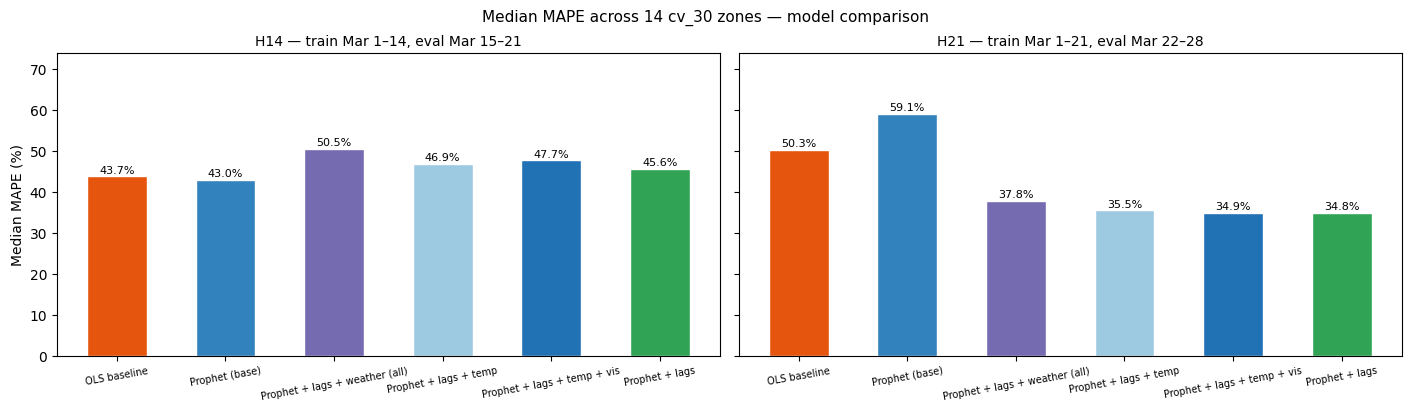

In [6]:
agg_median = (
    mape_df.groupby(["h_days", "model"])["mape"]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, constrained_layout=True)

for ax, (h_days, h_cfg) in zip(axes, HORIZONS.items()):
    sub    = agg_median[agg_median["h_days"] == h_days].set_index("model")
    colors = [MODEL_COLORS[m] for m in sub.index]
    bars   = ax.bar(
        [MODEL_LABELS[m] for m in sub.index],
        sub["mape"],
        color=colors, edgecolor="white", width=0.55,
    )
    for bar, val in zip(bars, sub["mape"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.set_title(h_cfg["label"], fontsize=10)
    ax.set_ylabel("Median MAPE (%)") if h_days == 14 else None
    ax.tick_params(axis="x", labelsize=7, rotation=10)
    ax.set_ylim(0, agg_median["mape"].max() * 1.25)

fig.suptitle("Median MAPE across 14 cv_30 zones — model comparison", fontsize=11)
plt.show()

### 5b. MAPE by eval day

Day-level MAPE breakdown (median across zones) for each model.  

In [7]:
day_mape_rows = []

for zone in ZONES:
    zone_df = zone_dfs[zone]
    for h_days, h_cfg in HORIZONS.items():
        eval_start = h_cfg["eval_start"]
        for day_i in range(7):
            day_start = eval_start + pd.Timedelta(days=day_i)
            day_end   = day_start  + pd.Timedelta(hours=23)

            actual_day = zone_df[
                (zone_df["ds"] >= day_start) & (zone_df["ds"] <= day_end)
            ]

            for model in MODELS:
                fc     = all_results[zone][h_days][model]["forecast"]
                fc_day = fc[
                    (pd.to_datetime(fc["ds"]) >= day_start) &
                    (pd.to_datetime(fc["ds"]) <= day_end)
                ]
                merged = actual_day[["ds", "y"]].merge(
                    fc_day[["ds", "yhat"]], on="ds", how="left"
                )
                day_mape_rows.append({
                    "zone":      zone,
                    "h_days":    h_days,
                    "model":     model,
                    "day_i":     day_i + 1,
                    "day_label": day_start.strftime("%a %d %b"),
                    "mape":      compute_mape(
                        merged["y"].reset_index(drop=True),
                        merged["yhat"].reset_index(drop=True),
                    ),
                })

day_mape_df = pd.DataFrame(day_mape_rows)
print(f"Day-level MAPE rows: {len(day_mape_df):,}")
day_mape_df.head(8)

Day-level MAPE rows: 1,176


,zone,h_days,model,day_i,day_label,mape
0,87194ad14ffffff,14,ols,1,Sun 15 Mar,38.184864
1,87194ad14ffffff,14,prophet_base,1,Sun 15 Mar,37.488979
2,87194ad14ffffff,14,prophet_lags,1,Sun 15 Mar,36.562905
3,87194ad14ffffff,14,prophet_full_temp,1,Sun 15 Mar,37.293361
4,87194ad14ffffff,14,prophet_full_temp_vis,1,Sun 15 Mar,37.288127
5,87194ad14ffffff,14,prophet_full,1,Sun 15 Mar,37.333306
6,87194ad14ffffff,14,ols,2,Mon 16 Mar,35.796556
7,87194ad14ffffff,14,prophet_base,2,Mon 16 Mar,37.669573


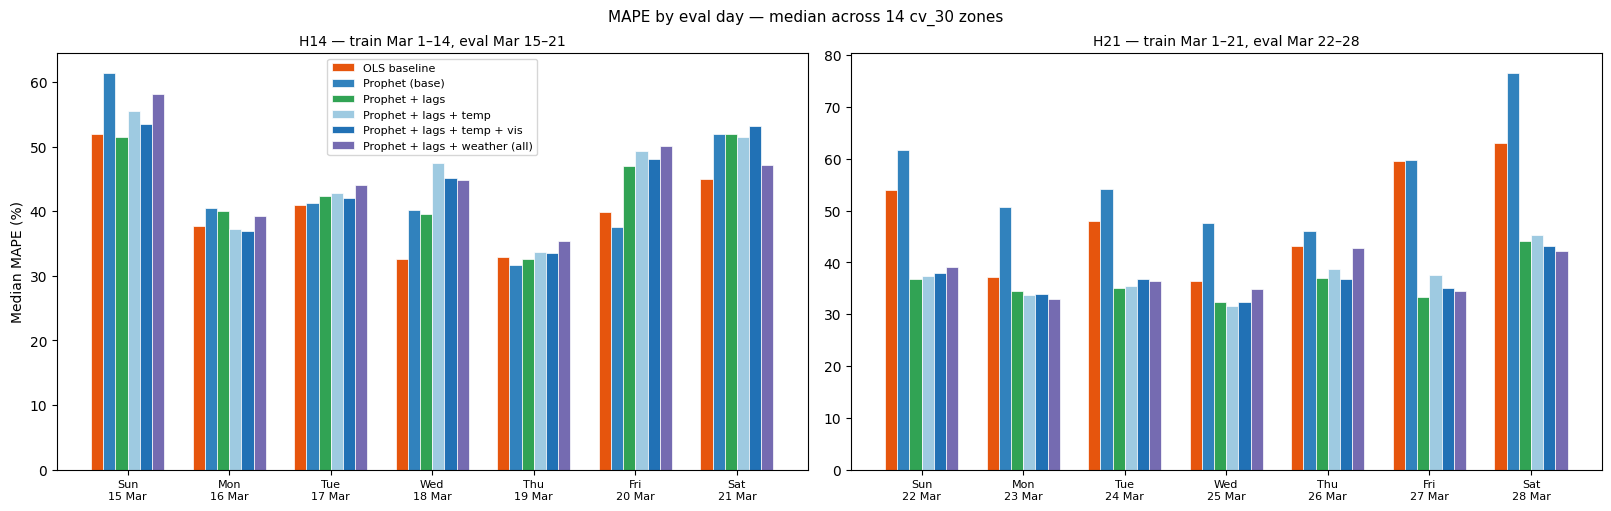

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

x     = np.arange(7)
width = 0.12

for ax, (h_days, h_cfg) in zip(axes, HORIZONS.items()):
    for i, model in enumerate(MODELS):
        sub = (
            day_mape_df[
                (day_mape_df["h_days"] == h_days) &
                (day_mape_df["model"]  == model)
            ]
            .groupby("day_i")["mape"].median()
            .reindex(range(1, 8))
        )
        offset = (i - (len(MODELS) - 1) / 2) * width
        ax.bar(x + offset, sub.values, width,
               color=MODEL_COLORS[model], label=MODEL_LABELS[model],
               edgecolor="white", linewidth=0.5)

    eval_start = h_cfg["eval_start"]
    day_labels = [
        (eval_start + pd.Timedelta(days=d)).strftime("%a\n%d %b")
        for d in range(7)
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(day_labels, fontsize=8)
    ax.set_ylabel("Median MAPE (%)") if h_days == 14 else None
    ax.set_title(h_cfg["label"], fontsize=10)
    if h_days == 14:
        ax.legend(fontsize=8)

fig.suptitle("MAPE by eval day — median across 14 cv_30 zones", fontsize=11)
plt.show()

## 5c. Grid search — Prophet + lags

Per-zone hyperparameter search over `changepoint_prior_scale` × `seasonality_prior_scale` for **prophet_lags**, evaluated on the H21 holdout (Mar 22–28).

**Grid:** 5 CPS values {0.001, 0.01, 0.05, 0.1, 0.5} × 4 SPS values {1, 5, 10, 20} = **20 combos × 14 zones = 280 Prophet fits**.

The heatmaps compare zone × day MAPE before and after tuning (same colour scale).  
The coverage table shows what fraction of hourly actuals fall inside the 95% credible interval for each zone after tuning.

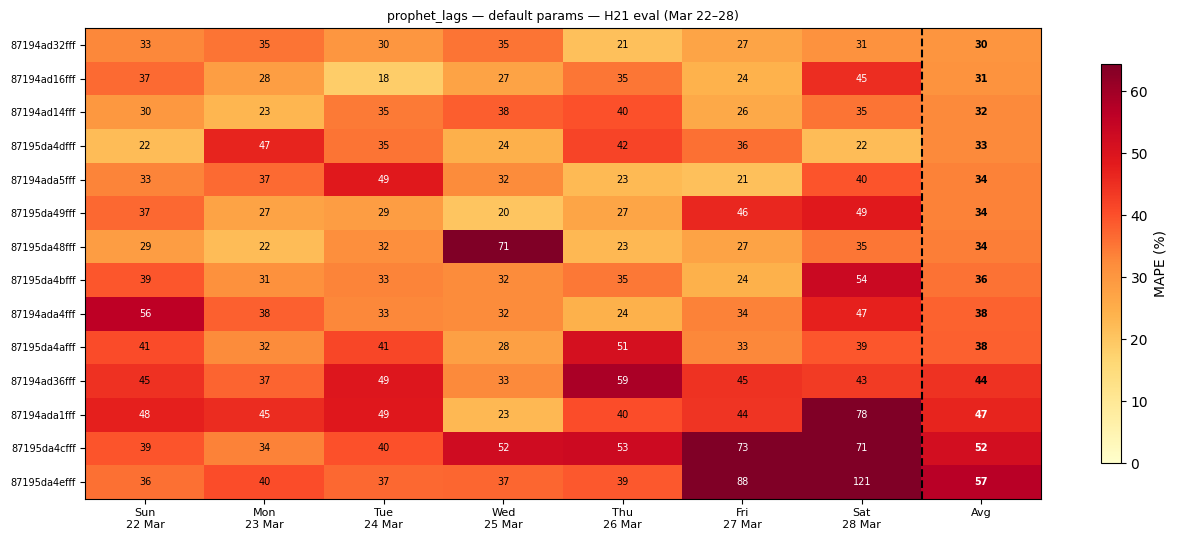

In [9]:
H21_CFG    = HORIZONS[21]
EVAL_START = H21_CFG["eval_start"]
DEFAULT_CPS, DEFAULT_SPS = 0.05, 10.0

# Conversion cutoff for March eval: only history up to start of eval week
CONV_CUTOFF_MAR = pd.Timestamp("2026-03-22 00:00:00", tz="UTC")

DAY_LABELS = [
    (EVAL_START + pd.Timedelta(days=i)).strftime("%a\n%d %b") for i in range(7)
]
COL_LABELS = DAY_LABELS + ["Avg"]

# ── Default params: prophet_lags ──────────────────────────────────────────────
pivot_lags_def = make_zone_day_pivot(day_mape_df, "prophet_lags", 21, COL_LABELS)
VMAX_LAGS = float(np.nanpercentile(pivot_lags_def.values, 95))

fig, ax = plt.subplots(figsize=(13, 5.5))
im = zone_day_heatmap(
    pivot_lags_def,
    "prophet_lags — default params — H21 eval (Mar 22–28)",
    VMAX_LAGS, ax,
)
plt.colorbar(im, ax=ax, label="MAPE (%)", shrink=0.85)
plt.tight_layout()
plt.show()

In [ ]:
PARAM_GRID = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 5.0, 10.0, 20.0],
}

gs_lags_results = {}
for zone in tqdm(ZONES, desc="Grid search (lags)"):
    gs_lags_results[zone] = run_zone_grid_search(
        zone_dfs[zone],
        param_grid = PARAM_GRID,
        train_end  = H21_CFG["train_end"],
        eval_start = H21_CFG["eval_start"],
        eval_end   = H21_CFG["eval_end"],
        variant    = "lags",
    )

# Best params per zone
best_lags_rows = []
for zone, gs_df in gs_lags_results.items():
    best         = gs_df.iloc[0]
    default_mape = gs_df.loc[
        (gs_df["changepoint_prior_scale"] == DEFAULT_CPS) &
        (gs_df["seasonality_prior_scale"] == DEFAULT_SPS), "mape"
    ].values[0]
    best_lags_rows.append({
        "zone":         zone,
        "cps":          best["changepoint_prior_scale"],
        "sps":          best["seasonality_prior_scale"],
        "mape_tuned":   round(best["mape"], 1),
        "mape_default": round(default_mape, 1),
        "gain":         round(default_mape - best["mape"], 1),
    })

best_lags_df = (
    pd.DataFrame(best_lags_rows)
    .sort_values("mape_tuned")
    .reset_index(drop=True)
)
print("Best params per zone (prophet_lags, H21):\n")
print(best_lags_df.to_string(index=False))


Tuned refit (lags):   0%|          | 0/14 [00:00<?, ?it/s]09:42:41 - cmdstanpy - INFO - Chain [1] start processing
09:42:41 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (lags):   7%|▋         | 1/14 [00:00<00:03,  3.89it/s]09:42:41 - cmdstanpy - INFO - Chain [1] start processing
09:42:41 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (lags):  14%|█▍        | 2/14 [00:00<00:02,  5.41it/s]09:42:41 - cmdstanpy - INFO - Chain [1] start processing
09:42:41 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (lags):  21%|██▏       | 3/14 [00:00<00:01,  6.19it/s]09:42:42 - cmdstanpy - INFO - Chain [1] start processing
09:42:42 - cmdstanpy - INFO - Chain [1] done processing
09:42:42 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
09:42:42 - cmdstanpy - INFO - Chain [1] start processing
09:42:42 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (lags):  29%|██▊       | 4

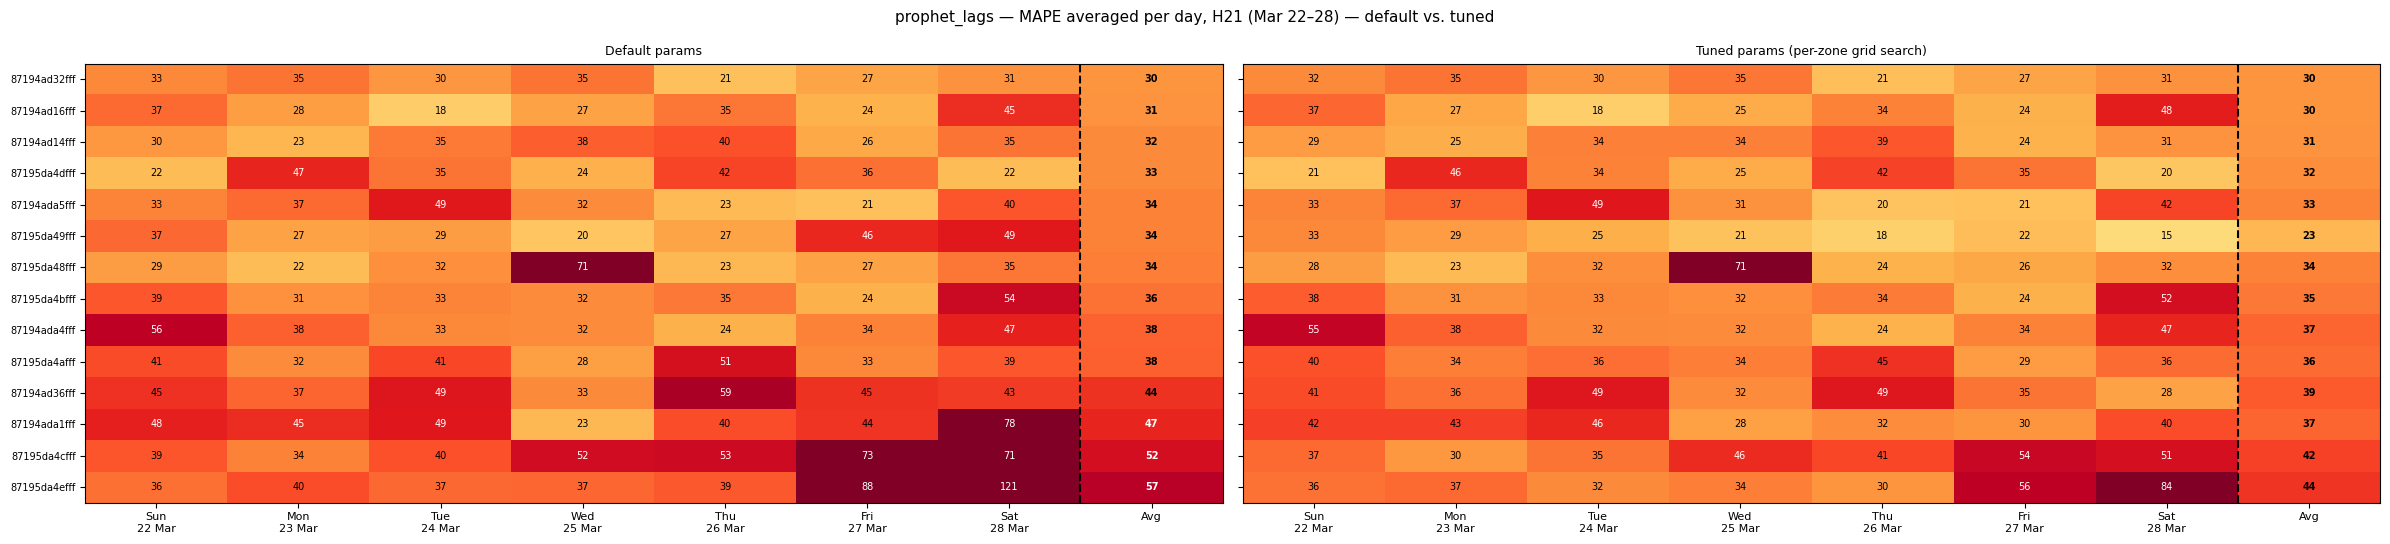

95% CI coverage per zone — prophet_lags (tuned), H21 eval (Mar 22–28):

                 coverage (%)
zone                         
87194ad14ffffff          91.1
87195da4dffffff          91.1
87195da4affffff          92.3
87194ad36ffffff          92.3
87194ada5ffffff          92.9
87195da4bffffff          92.9
87194ad32ffffff          93.5
87194ada4ffffff          93.5
87195da48ffffff          94.6
87194ada1ffffff          94.6
87195da4cffffff          94.6
87195da49ffffff          95.2
87195da4effffff          95.8
87194ad16ffffff          97.0

Median Avg MAPE     — default : 34.8%
Median Avg MAPE     — tuned   : 34.3%
Median Avg Coverage — tuned   : 93.5%  (target 95%)


In [11]:
best_lags_params = {row["zone"]: (row["cps"], row["sps"]) for _, row in best_lags_df.iterrows()}

tuned_lags_rows = []
for zone in tqdm(ZONES, desc="Tuned refit (lags)"):
    zone_df = zone_dfs[zone]
    train   = zone_df[zone_df["ds"] <= H21_CFG["train_end"]]
    eval_   = zone_df[
        (zone_df["ds"] >= H21_CFG["eval_start"]) &
        (zone_df["ds"] <= H21_CFG["eval_end"])
    ].copy()

    cps_val, sps_val = best_lags_params[zone]
    m  = build_prophet_model("lags",
                             changepoint_prior_scale=cps_val,
                             seasonality_prior_scale=sps_val)
    fc = fit_and_forecast(m, train, eval_[["ds", "lag_1w", "lag_2w"]])

    for day_i in range(7):
        ds   = H21_CFG["eval_start"] + pd.Timedelta(days=day_i)
        de   = ds + pd.Timedelta(hours=23)
        act  = eval_[(eval_["ds"] >= ds) & (eval_["ds"] <= de)]
        pred = fc[(pd.to_datetime(fc["ds"]) >= ds) & (pd.to_datetime(fc["ds"]) <= de)]
        merged = act[["ds", "y"]].merge(
            pred[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds", how="left"
        )
        in_ci = (merged["y"] >= merged["yhat_lower"]) & (merged["y"] <= merged["yhat_upper"])
        tuned_lags_rows.append({
            "zone":     zone,
            "day_i":    day_i + 1,
            "mape":     compute_mape(merged["y"].reset_index(drop=True),
                                     merged["yhat"].reset_index(drop=True)),
            "coverage": in_ci.mean() * 100,
        })

lags_tuned_df = pd.DataFrame(tuned_lags_rows)
lags_pivots   = build_metric_pivots(lags_tuned_df, pivot_lags_def.index, COL_LABELS)

plot_heatmap_pair(
    pivot_lags_def, lags_pivots["mape"], VMAX_LAGS,
    "prophet_lags — MAPE averaged per day, H21 (Mar 22–28) — default vs. tuned",
)
print_mape_cov_summary(pivot_lags_def, lags_pivots, "prophet_lags")

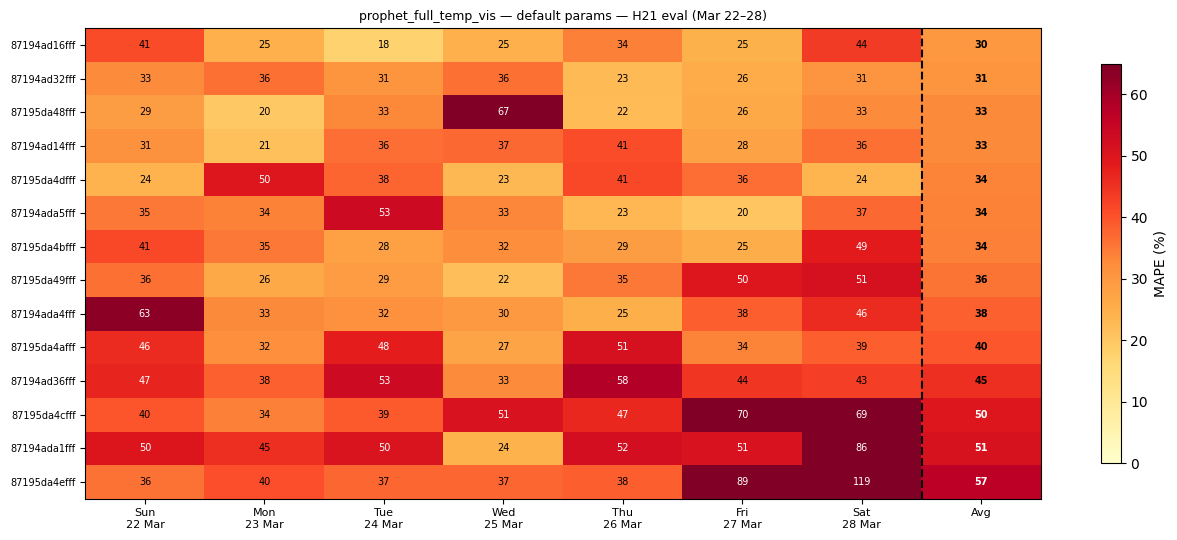

In [12]:
# ── Default params: prophet_full_temp_vis ─────────────────────────────────────
pivot_def = make_zone_day_pivot(day_mape_df, "prophet_full_temp_vis", 21, COL_LABELS)
VMAX = float(np.nanpercentile(pivot_def.values, 95))

fig, ax = plt.subplots(figsize=(13, 5.5))
im = zone_day_heatmap(
    pivot_def,
    "prophet_full_temp_vis — default params — H21 eval (Mar 22–28)",
    VMAX, ax,
)
plt.colorbar(im, ax=ax, label="MAPE (%)", shrink=0.85)
plt.tight_layout()
plt.show()

## 5d. Grid search — Prophet + lags + temp + vis

Same grid search as 5c for **prophet_full_temp_vis** — extends the lag baseline with `temperature_2m` and `visibility` regressors.

**Grid:** 5 × 4 = **20 combos × 14 zones = 280 Prophet fits**.

This model is selected as the **production model** for April forecasting based on consistently lower MAPE and better CI coverage versus `prophet_lags` across most zones.  
Per-zone best `(changepoint_prior_scale, seasonality_prior_scale)` pairs from this search are carried forward to section 6, 7, and 8.

In [ ]:
PARAM_GRID = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 5.0, 10.0, 20.0],
}

gs_tv_results = {}
for zone in tqdm(ZONES, desc="Grid search (temp+vis)"):
    gs_tv_results[zone] = run_zone_grid_search(
        zone_dfs[zone],
        param_grid = PARAM_GRID,
        train_end  = H21_CFG["train_end"],
        eval_start = H21_CFG["eval_start"],
        eval_end   = H21_CFG["eval_end"],
        variant    = "full_temp_vis",
    )

print("Grid search complete.")


In [ ]:
DEFAULT_CPS, DEFAULT_SPS = 0.05, 10.0

best_tv_rows = []
for zone, gs_df in gs_tv_results.items():
    best         = gs_df.iloc[0]
    default_mape = gs_df.loc[
        (gs_df["changepoint_prior_scale"] == DEFAULT_CPS) &
        (gs_df["seasonality_prior_scale"] == DEFAULT_SPS), "mape"
    ].values[0]
    best_tv_rows.append({
        "zone":         zone,
        "cps":          best["changepoint_prior_scale"],
        "sps":          best["seasonality_prior_scale"],
        "mape_tuned":   round(best["mape"], 1),
        "mape_default": round(default_mape, 1),
        "gain":         round(default_mape - best["mape"], 1),
    })

best_tv_df = (
    pd.DataFrame(best_tv_rows)
    .sort_values("mape_tuned")
    .reset_index(drop=True)
)
print("Best params per zone (prophet_full_temp_vis, H21):\n")
print(best_tv_df.to_string(index=False))


Tuned refit (temp+vis):   0%|          | 0/14 [00:00<?, ?it/s]09:44:05 - cmdstanpy - INFO - Chain [1] start processing
09:44:05 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (temp+vis):   7%|▋         | 1/14 [00:00<00:03,  4.21it/s]09:44:05 - cmdstanpy - INFO - Chain [1] start processing
09:44:05 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (temp+vis):  14%|█▍        | 2/14 [00:00<00:02,  5.65it/s]09:44:05 - cmdstanpy - INFO - Chain [1] start processing
09:44:06 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (temp+vis):  21%|██▏       | 3/14 [00:00<00:02,  5.42it/s]09:44:06 - cmdstanpy - INFO - Chain [1] start processing
09:44:06 - cmdstanpy - INFO - Chain [1] done processing
09:44:06 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
09:44:06 - cmdstanpy - INFO - Chain [1] start processing
09:44:06 - cmdstanpy - INFO - Chain [1] done processing
Tuned refit (temp+vis)

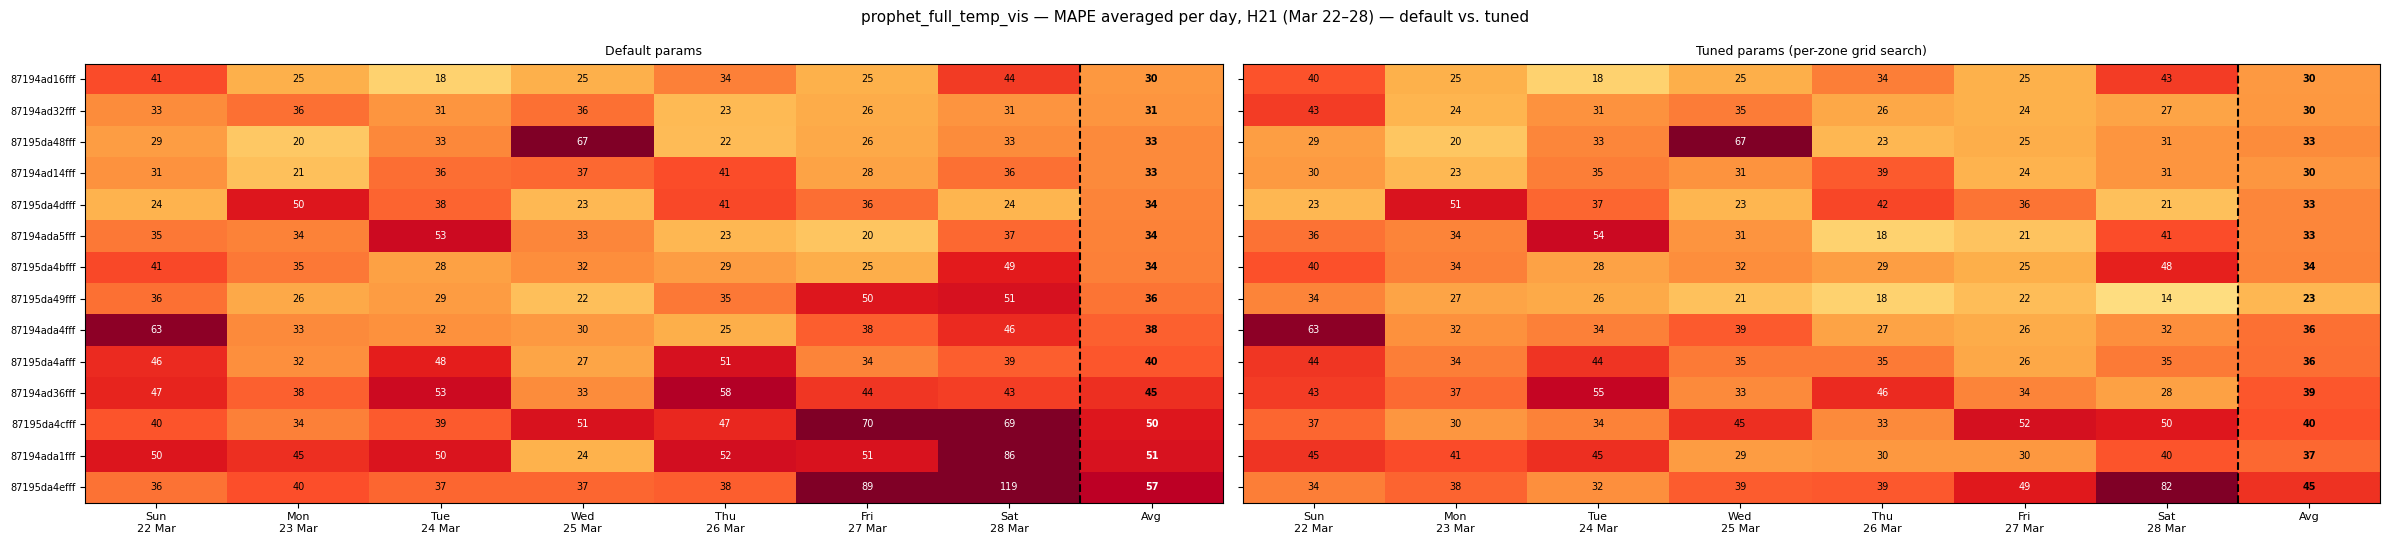

95% CI coverage per zone — prophet_full_temp_vis (tuned), H21 eval (Mar 22–28):

                 coverage (%)
zone                         
87194ad14ffffff          89.9
87194ada4ffffff          90.5
87195da4bffffff          91.1
87195da4dffffff          91.7
87194ad36ffffff          91.7
87194ada5ffffff          92.9
87195da4affffff          93.5
87195da49ffffff          94.6
87195da4cffffff          94.6
87194ada1ffffff          94.6
87195da48ffffff          95.2
87195da4effffff          95.2
87194ad16ffffff          97.0
87194ad32ffffff          97.6

Median Avg MAPE     — default : 34.9%
Median Avg MAPE     — tuned   : 33.5%
Median Avg Coverage — tuned   : 94.0%  (target 95%)


In [15]:
weather_tv  = _VARIANT_WEATHER["full_temp_vis"]
best_params = {row["zone"]: (row["cps"], row["sps"]) for _, row in best_tv_df.iterrows()}

tuned_tv_rows = []
for zone in tqdm(ZONES, desc="Tuned refit (temp+vis)"):
    zone_df = zone_dfs[zone]
    train   = zone_df[zone_df["ds"] <= H21_CFG["train_end"]]
    eval_   = zone_df[
        (zone_df["ds"] >= H21_CFG["eval_start"]) &
        (zone_df["ds"] <= H21_CFG["eval_end"])
    ].copy()

    cps_val, sps_val = best_params[zone]
    m  = build_prophet_model("full_temp_vis",
                             changepoint_prior_scale=cps_val,
                             seasonality_prior_scale=sps_val)
    fc = fit_and_forecast(m, train, eval_[["ds", "lag_1w", "lag_2w"] + weather_tv])

    for day_i in range(7):
        ds  = H21_CFG["eval_start"] + pd.Timedelta(days=day_i)
        de  = ds + pd.Timedelta(hours=23)
        act = eval_[(eval_["ds"] >= ds) & (eval_["ds"] <= de)]
        pred = fc[(pd.to_datetime(fc["ds"]) >= ds) & (pd.to_datetime(fc["ds"]) <= de)]
        merged = act[["ds", "y"]].merge(
            pred[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds", how="left"
        )
        in_ci = (merged["y"] >= merged["yhat_lower"]) & (merged["y"] <= merged["yhat_upper"])
        tuned_tv_rows.append({
            "zone":     zone,
            "day_i":    day_i + 1,
            "mape":     compute_mape(merged["y"].reset_index(drop=True),
                                     merged["yhat"].reset_index(drop=True)),
            "coverage": in_ci.mean() * 100,
        })

tv_tuned_df = pd.DataFrame(tuned_tv_rows)
tv_pivots   = build_metric_pivots(tv_tuned_df, pivot_def.index, COL_LABELS)

plot_heatmap_pair(
    pivot_def, tv_pivots["mape"], VMAX,
    "prophet_full_temp_vis — MAPE averaged per day, H21 (Mar 22–28) — default vs. tuned",
)
print_mape_cov_summary(pivot_def, tv_pivots, "prophet_full_temp_vis")

## 6. Best zone — seasonality, CI, and conversion

Deep-dive into the single best-performing zone (lowest average MAPE under tuned `prophet_full_temp_vis`, H21 eval Mar 22–28).

| Sub-section | Content |
|---|---|
| **6a** | Prophet component plots — trend, daily/weekly seasonality, holiday effects, regressor partial effects |
| **6b** | Hourly actual vs forecast with 95% credible interval band + per-hour MAPE bar chart |
| **6c** | Hourly table (Mar 22–28): `yhat_lower / yhat / yhat_upper` × historical conversion → trip estimates |
| **6d** | All-zone H3 demand maps at 19:00 Tue 24 Mar 2026 — lower / predicted / upper bound × conversion |

### 6a. Best zone — Prophet component plots

Refit the tuned `prophet_full_temp_vis` model for the best zone and call `plot_components()`.  
Components shown: **trend**, **daily seasonality** (Fourier order 8), **weekly seasonality** (Fourier order 3), **UK public holidays**, and partial effects of `lag_1w`, `lag_2w`, `temperature_2m`, and `visibility`.

Best zone : 87195da49ffffff
Avg MAPE  : 23.2%  (tuned prophet_full_temp_vis, H21 Mar 22–28)


09:44:14 - cmdstanpy - INFO - Chain [1] start processing
09:44:14 - cmdstanpy - INFO - Chain [1] done processing
09:44:14 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
09:44:14 - cmdstanpy - INFO - Chain [1] start processing
09:44:14 - cmdstanpy - INFO - Chain [1] done processing


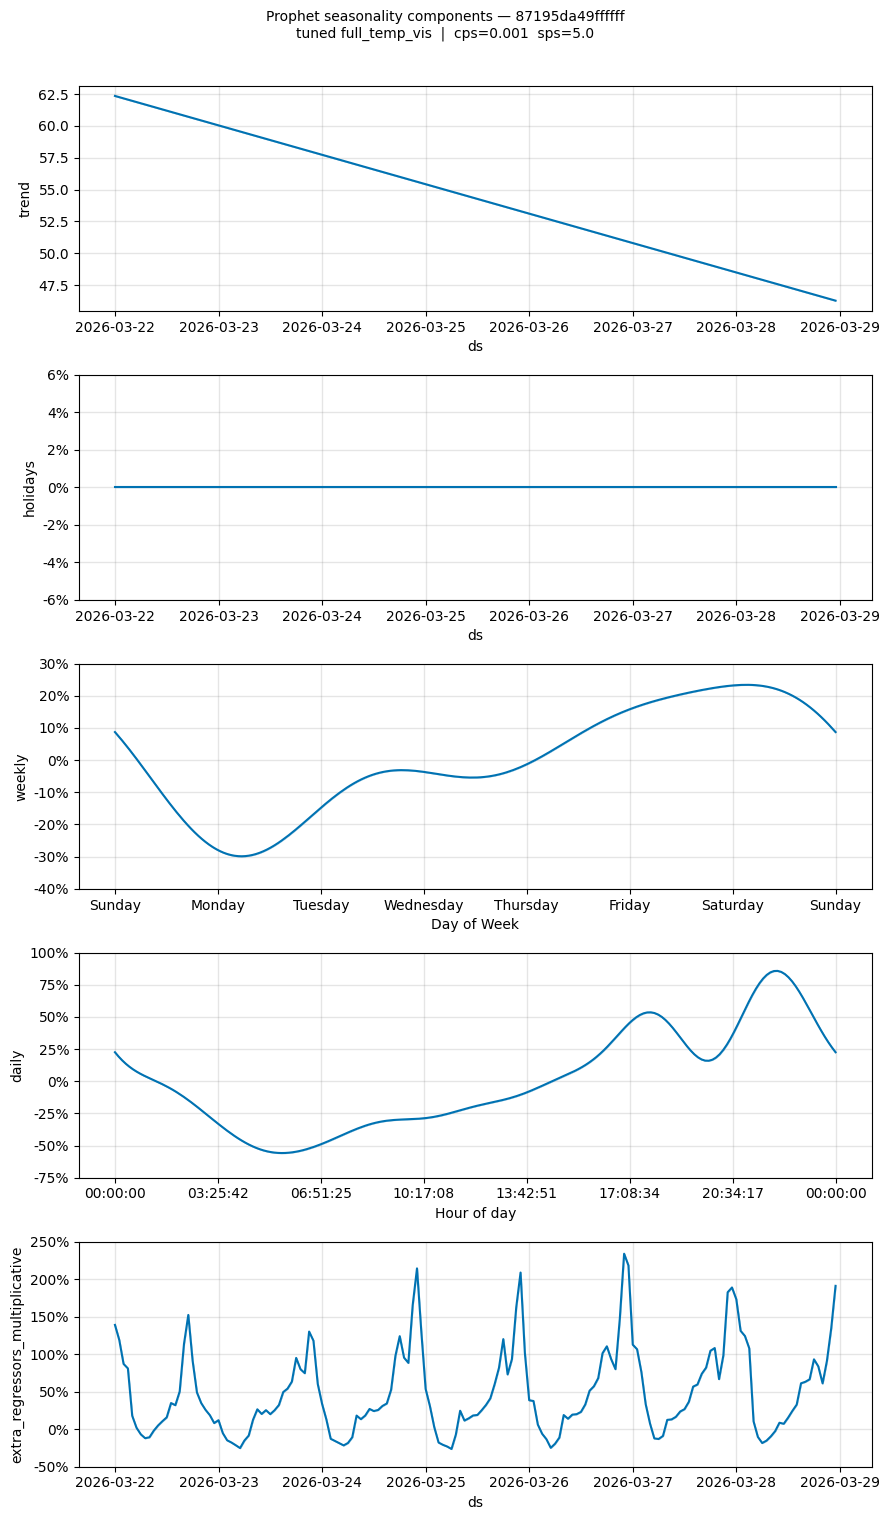

In [16]:
# ── Best zone: lowest Avg MAPE (tuned prophet_full_temp_vis) ─────────────────
best_zone      = tv_pivots["mape"]["Avg"].idxmin()
best_zone_mape = tv_pivots["mape"].loc[best_zone, "Avg"]
print(f"Best zone : {best_zone}")
print(f"Avg MAPE  : {best_zone_mape:.1f}%  (tuned prophet_full_temp_vis, H21 Mar 22–28)")

# ── Refit keeping the model object for plot_components ───────────────────────
weather_tv     = _VARIANT_WEATHER["full_temp_vis"]
cps_bz, sps_bz = best_params[best_zone]

bz_df    = zone_dfs[best_zone]
bz_train = bz_df[bz_df["ds"] <= H21_CFG["train_end"]]
bz_eval  = bz_df[
    (bz_df["ds"] >= H21_CFG["eval_start"]) &
    (bz_df["ds"] <= H21_CFG["eval_end"])
].copy()

m_bz = build_prophet_model(
    "full_temp_vis",
    changepoint_prior_scale=cps_bz,
    seasonality_prior_scale=sps_bz,
)
m_bz.fit(bz_train)

future_bz  = bz_eval[["ds", "lag_1w", "lag_2w"] + weather_tv].copy()
fc_bz_full = m_bz.predict(future_bz)
fc_bz_full["yhat"] = fc_bz_full["yhat"].clip(lower=0)

# ── All Prophet components ────────────────────────────────────────────────────
fig_comp = m_bz.plot_components(fc_bz_full)
fig_comp.suptitle(
    f"Prophet seasonality components — {best_zone}\n"
    f"tuned full_temp_vis  |  cps={cps_bz}  sps={sps_bz}",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

### 6b. Hourly actual vs forecast with 95% credible interval

Hour-by-hour comparison for Mar 22–28 for the best zone.  
Upper panel: actual demand (black), `yhat` (blue line), 95% CI band.  
Lower panel: per-hour absolute percentage error — highlights the hours and days where the model struggles most.

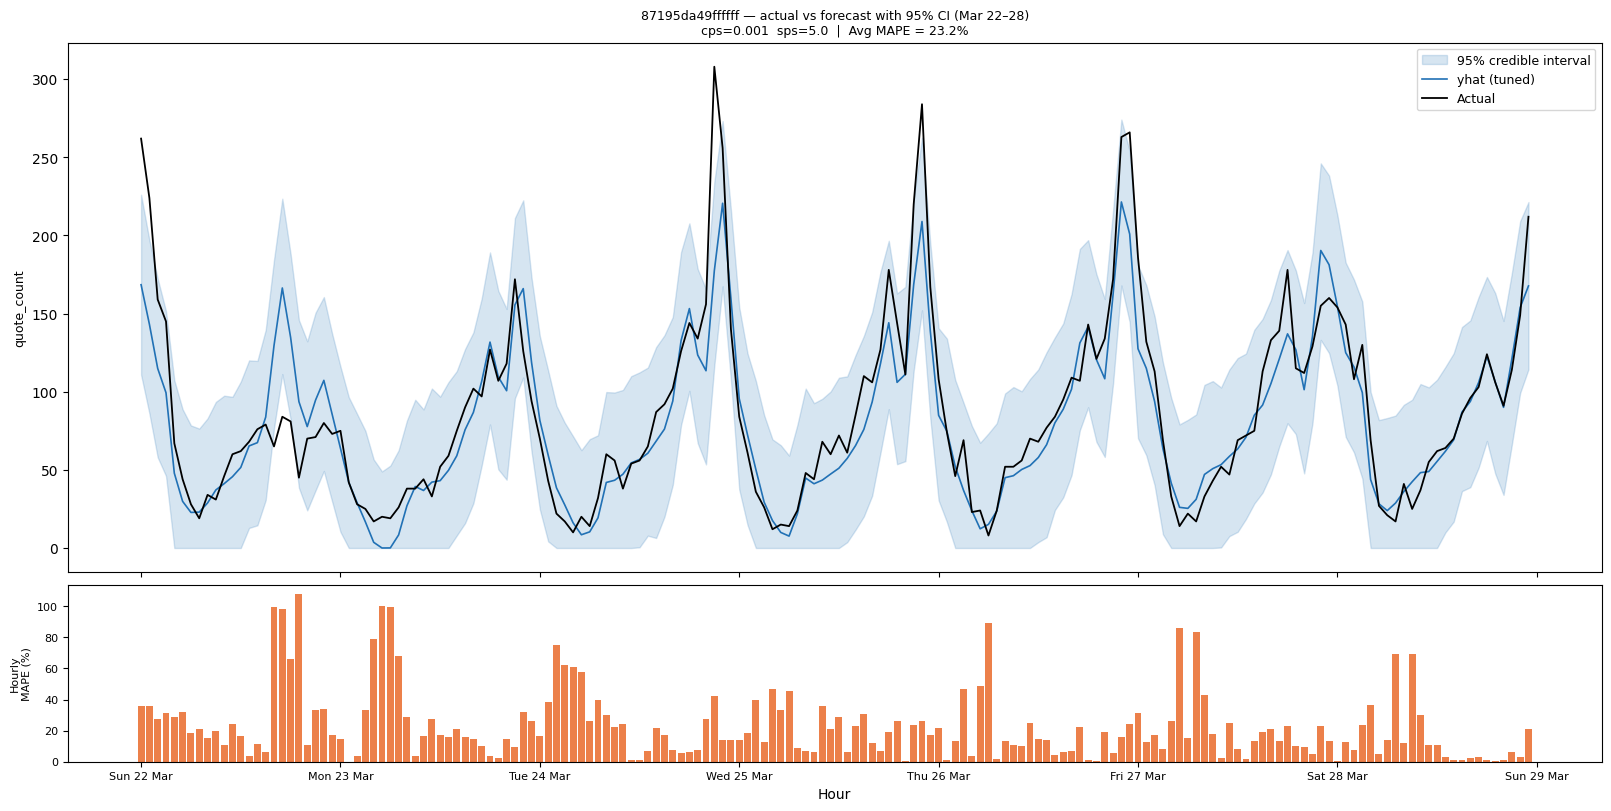

In [17]:
# ── Merge actuals and forecast ────────────────────────────────────────────────
bz_merged = bz_eval[["ds", "y"]].merge(
    fc_bz_full[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="left",
)
bz_merged["yhat_lower"] = bz_merged["yhat_lower"].clip(0)
bz_merged["mape_hr"] = (
    (bz_merged["y"] - bz_merged["yhat"]).abs()
    / bz_merged["y"].replace(0, np.nan)
    * 100
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 8), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax1.fill_between(
    bz_merged["ds"],
    bz_merged["yhat_lower"], bz_merged["yhat_upper"],
    color="#2171b5", alpha=0.18, label="95% credible interval",
)
ax1.plot(bz_merged["ds"], bz_merged["yhat"],
         color="#2171b5", linewidth=1.2, label="yhat (tuned)")
ax1.plot(bz_merged["ds"], bz_merged["y"],
         color="black", linewidth=1.3, label="Actual", zorder=5)
ax1.set_ylabel("quote_count", fontsize=9)
ax1.legend(fontsize=9)
ax1.set_title(
    f"{best_zone} — actual vs forecast with 95% CI (Mar 22–28)\n"
    f"cps={cps_bz}  sps={sps_bz}  |  Avg MAPE = {best_zone_mape:.1f}%",
    fontsize=9,
)

ax2.bar(bz_merged["ds"], bz_merged["mape_hr"],
        width=0.035, color="#e6550d", alpha=0.75)
ax2.set_ylabel("Hourly\nMAPE (%)", fontsize=8)
ax2.set_xlabel("Hour")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
ax2.tick_params(labelsize=8)

plt.show()

### 6c. Hourly table — forecasts, conversion, and trip estimates (Mar 22–28)

168-row table (24 hours × 7 days) for the best zone.  
Conversion rates are the historical mean per `(hour × day-of-week)` computed from Mar 1–21 only (no leakage into the eval week).

| Column | Description |
|---|---|
| `yhat_lower / yhat / yhat_upper` | Prophet 95% credible interval on quote demand |
| `conv_rate` | Historical conversion: `trip_count / quote_count` for that hour × weekday |
| `trips_lower / trips_pred / trips_upper` | Demand bounds × conversion rate |

In [ ]:
# Historical conversion: only Mar 1–21 (no leakage into eval week)
conv_hist_bz = compute_historical_conversion(df, best_zone, CONV_CUTOFF_MAR)
bz_table     = apply_conversion_to_forecast(bz_merged, conv_hist_bz)

display_cols = [
    "ds", "yhat_lower", "yhat", "yhat_upper",
    "conv_rate", "trips_lower", "trips_pred", "trips_upper",
]
display(
    bz_table[display_cols].style.format({
        "ds":          lambda x: str(x),
        "yhat_lower":  "{:.1f}",
        "yhat":        "{:.1f}",
        "yhat_upper":  "{:.1f}",
        "conv_rate":   "{:.3f}",
        "trips_lower": "{:.2f}",
        "trips_pred":  "{:.2f}",
        "trips_upper": "{:.2f}",
    })
)

### 6d. All-zone demand maps — 19:00 Tue 24 Mar 2026

Refit the tuned `prophet_full_temp_vis` model for **all 14 cv_30 zones** and extract the prediction at 19:00 on 24 March.  
Three maps show lower-bound, forecast, and upper-bound trip estimates (demand × conversion rate) as H3 hexagons coloured by value.

> Conversion rates use Mar 1–21 history (matching the eval window cutoff in 6c).

Refit for map (19:00 Mar 24):   0%|          | 0/14 [00:00<?, ?it/s]09:45:50 - cmdstanpy - INFO - Chain [1] start processing
09:45:50 - cmdstanpy - INFO - Chain [1] done processing
Refit for map (19:00 Mar 24):   7%|▋         | 1/14 [00:00<00:04,  3.14it/s]09:45:50 - cmdstanpy - INFO - Chain [1] start processing
09:45:50 - cmdstanpy - INFO - Chain [1] done processing
Refit for map (19:00 Mar 24):  14%|█▍        | 2/14 [00:00<00:02,  4.58it/s]09:45:50 - cmdstanpy - INFO - Chain [1] start processing
09:45:50 - cmdstanpy - INFO - Chain [1] done processing
Refit for map (19:00 Mar 24):  21%|██▏       | 3/14 [00:00<00:02,  4.73it/s]09:45:50 - cmdstanpy - INFO - Chain [1] start processing
09:45:50 - cmdstanpy - INFO - Chain [1] done processing
09:45:50 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
09:45:50 - cmdstanpy - INFO - Chain [1] start processing
09:45:51 - cmdstanpy - INFO - Chain [1] done processin

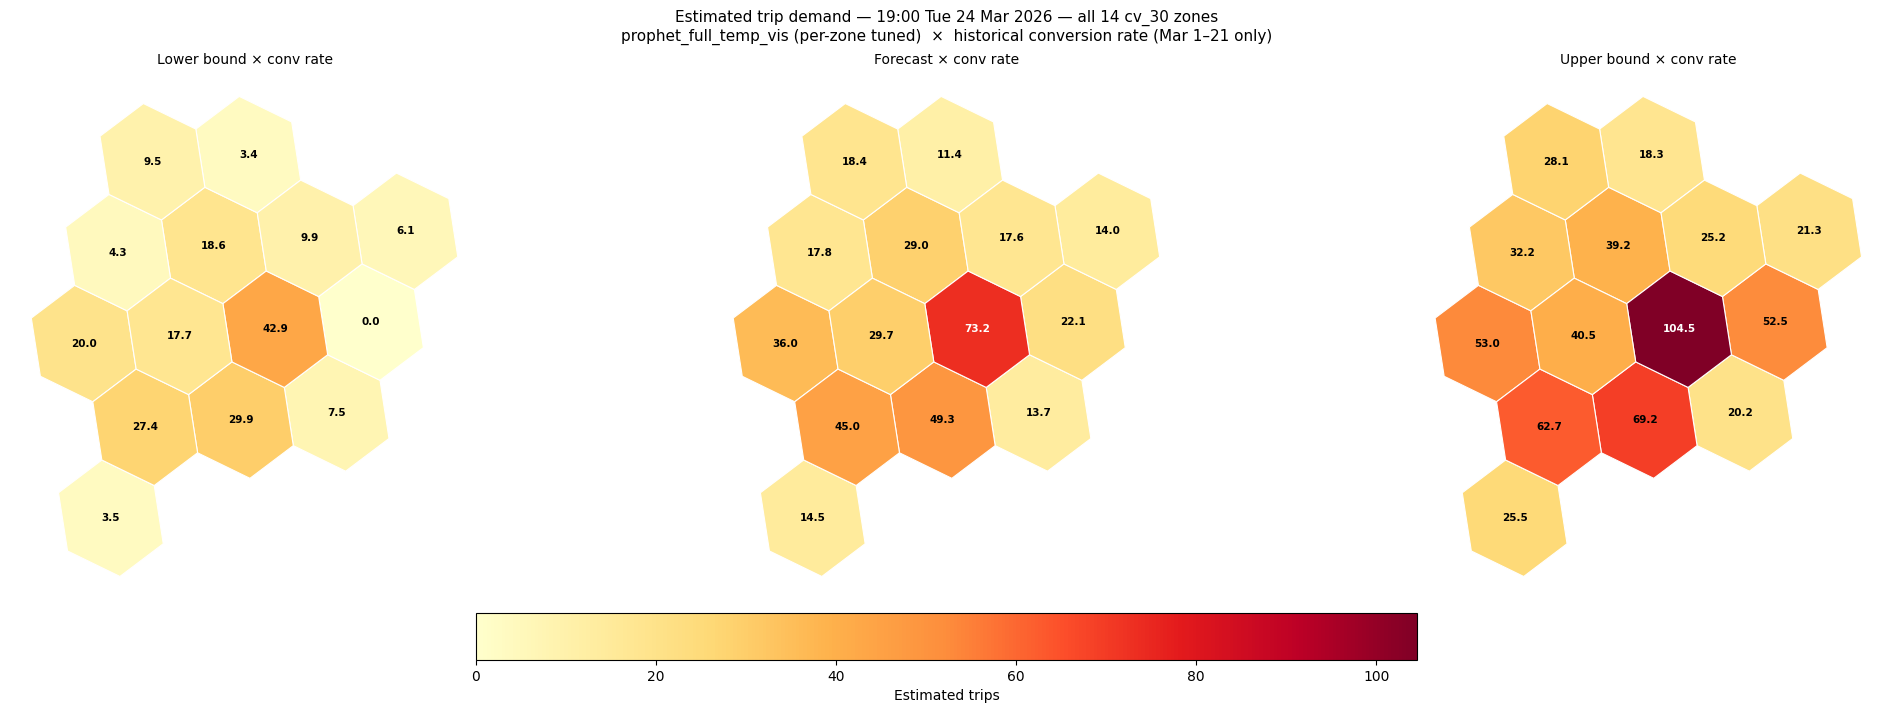

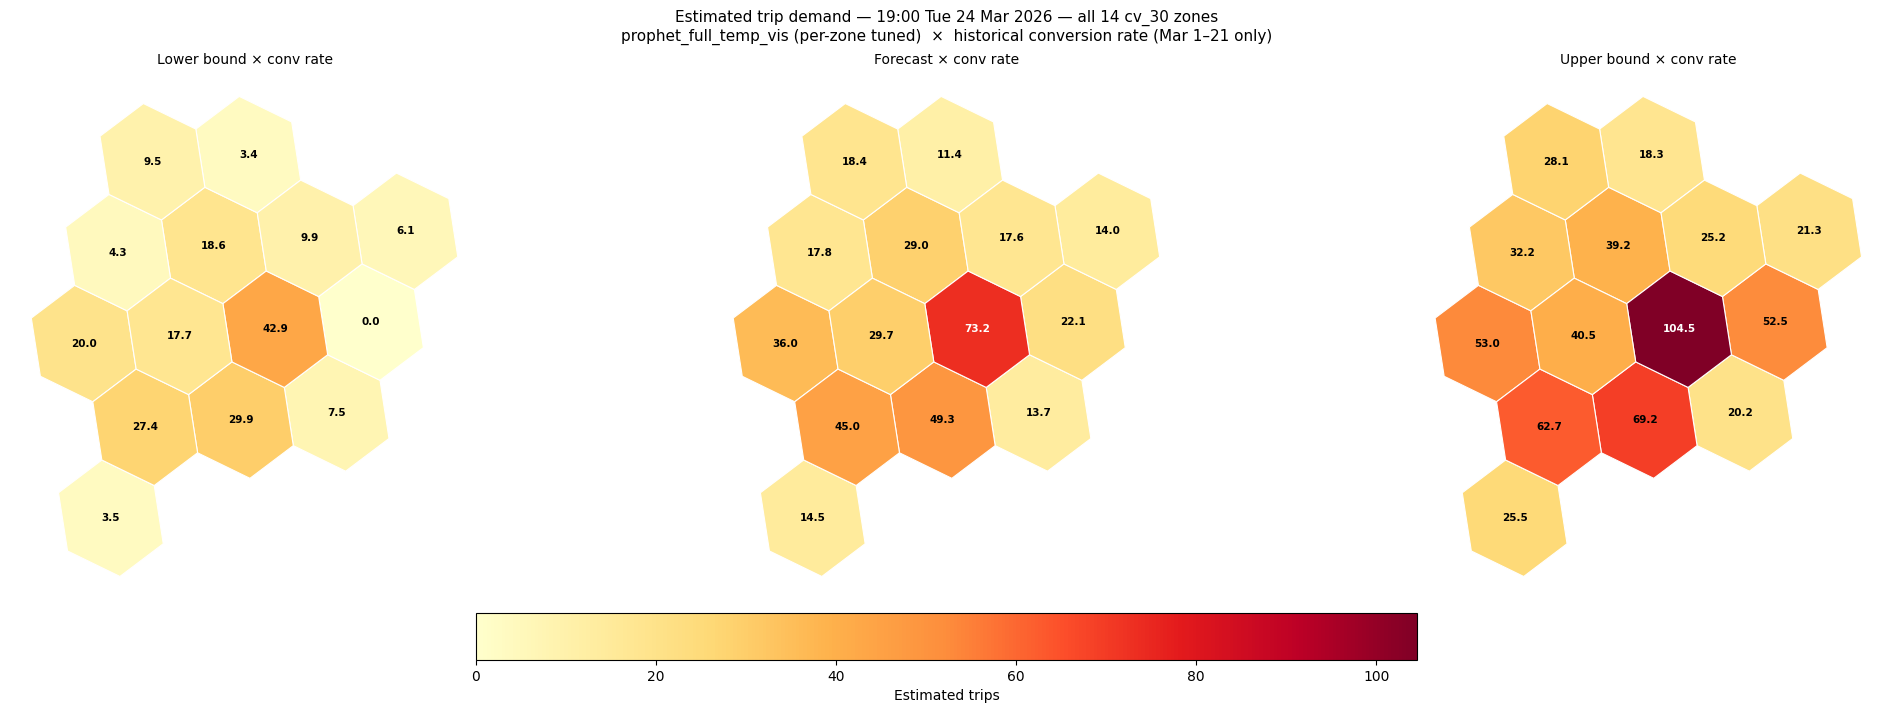

In [26]:
TARGET_TS   = pd.Timestamp("2026-03-24 19:00:00")   # Tuesday
TARGET_HOUR = 19
TARGET_DOW  = TARGET_TS.dayofweek                   # 1 = Tuesday

# Pre-compute conversion tables per zone (Mar 1–21 only — no leakage)
conv_dfs_mar = {
    z: compute_historical_conversion(df, z, CONV_CUTOFF_MAR)
    for z in ZONES
}

# ── Refit all zones and extract prediction at TARGET_TS ───────────────────────
map_rows = []
for zone in tqdm(ZONES, desc="Refit for map (19:00 Mar 24)"):
    zone_df = zone_dfs[zone]
    train   = zone_df[zone_df["ds"] <= H21_CFG["train_end"]]
    eval_   = zone_df[
        (zone_df["ds"] >= H21_CFG["eval_start"]) &
        (zone_df["ds"] <= H21_CFG["eval_end"])
    ].copy()

    cps_v, sps_v = best_params[zone]
    m  = build_prophet_model("full_temp_vis",
                             changepoint_prior_scale=cps_v,
                             seasonality_prior_scale=sps_v)
    fc = fit_and_forecast(m, train, eval_[["ds", "lag_1w", "lag_2w"] + weather_tv])

    row_fc = fc[pd.to_datetime(fc["ds"]) == TARGET_TS]
    if len(row_fc) == 0:
        continue

    row_enriched = apply_conversion_to_forecast(row_fc, conv_dfs_mar[zone])
    r = row_enriched.iloc[0]
    map_rows.append({
        "zone":        zone,
        "yhat_lower":  float(r["yhat_lower"]),
        "yhat":        float(r["yhat"]),
        "yhat_upper":  float(r["yhat_upper"]),
        "conv_rate":   float(r["conv_rate"]),
        "trips_lower": float(r["trips_lower"]),
        "trips_pred":  float(r["trips_pred"]),
        "trips_upper": float(r["trips_upper"]),
    })

map_df  = pd.DataFrame(map_rows)
gdf_map = h3_ids_to_geodataframe(map_df)

scenario_cols   = ["trips_lower", "trips_pred", "trips_upper"]
scenario_labels = ["Lower bound × conv rate", "Forecast × conv rate", "Upper bound × conv rate"]

plot_h3_demand_maps(
    gdf_map, scenario_cols, scenario_labels,
    "Estimated trip demand — 19:00 Tue 24 Mar 2026 — all 14 cv_30 zones\n"
    "prophet_full_temp_vis (per-zone tuned)  ×  historical conversion rate (Mar 1–21 only)",
)


## 8. April 1–7 production forecast

Train on full March (Mar 1–31) using the per-zone tuned **prophet_full_temp_vis** model.

**Lag sources** (no lookahead — all from observed March data):

| Regressor | Source window |
|---|---|
| `lag_1w` | Mar 25–31 (same hour, 1 week prior) |
| `lag_2w` | Mar 18–24 (same hour, 2 weeks prior) |

**Weather:** `weather_forecast_apr2026.parquet`  
**Conversion rates:** historical mean per `(hour × day-of-week)` using Mar 1–31 — no leakage into April.

Outputs per zone and hour: `yhat_lower / yhat / yhat_upper` (quote demand) and `trips_lower / trips_pred / trips_upper` (demand × conversion rate).

In [20]:
APR_NAIVE      = pd.date_range(
    APR_START.tz_localize(None), APR_END.tz_localize(None), freq="h"
)
PROD_TRAIN_END  = pd.Timestamp("2026-03-31 23:00:00")
CONV_CUTOFF_APR = pd.Timestamp("2026-04-01 00:00:00", tz="UTC")   # full March available
weather_tv      = _VARIANT_WEATHER["full_temp_vis"]

# Pre-compute per-zone conversion tables once (Mar 1–31, no leakage into April)
conv_dfs_apr = {
    z: compute_historical_conversion(df, z, CONV_CUTOFF_APR)
    for z in ZONES
}

apr_records = []

for zone in tqdm(ZONES, desc="April forecast"):
    zone_df = zone_dfs[zone]
    train   = zone_df[zone_df["ds"] <= PROD_TRAIN_END]

    # Lag values from March series
    ds_to_y    = zone_df.set_index("ds")["y"].to_dict()
    apr_future = pd.DataFrame({"ds": APR_NAIVE})
    apr_future["lag_1w"] = [
        ds_to_y.get(ts - pd.Timedelta(weeks=1), 0) for ts in APR_NAIVE
    ]
    apr_future["lag_2w"] = [
        ds_to_y.get(ts - pd.Timedelta(weeks=2), 0) for ts in APR_NAIVE
    ]

    # April weather (same across zones)
    apr_future = apr_future.merge(
        weather_apr[["ds"] + WEATHER_REGRESSORS], on="ds", how="left"
    )
    apr_future[WEATHER_REGRESSORS] = apr_future[WEATHER_REGRESSORS].fillna(0)

    # Tuned prophet_full_temp_vis with per-zone best params
    cps_v, sps_v = best_params[zone]
    m  = build_prophet_model("full_temp_vis",
                             changepoint_prior_scale=cps_v,
                             seasonality_prior_scale=sps_v)
    fc = fit_and_forecast(m, train, apr_future[["ds", "lag_1w", "lag_2w"] + weather_tv])

    # Join conversion and compute trip estimates (ds still tz-naive here)
    fc = apply_conversion_to_forecast(fc, conv_dfs_apr[zone])
    fc["zone"] = zone
    apr_records.append(fc)

apr_forecast_df = pd.concat(apr_records, ignore_index=True)
apr_forecast_df["ds"] = pd.to_datetime(apr_forecast_df["ds"]).dt.tz_localize("UTC")

print(f"April forecast rows: {len(apr_forecast_df):,}")
apr_forecast_df[DEMAND_FORECAST_COLS].head(10)

April forecast:   0%|          | 0/14 [00:00<?, ?it/s]09:44:25 - cmdstanpy - INFO - Chain [1] start processing
09:44:25 - cmdstanpy - INFO - Chain [1] done processing
April forecast:   7%|▋         | 1/14 [00:00<00:03,  4.13it/s]09:44:25 - cmdstanpy - INFO - Chain [1] start processing
09:44:25 - cmdstanpy - INFO - Chain [1] done processing
April forecast:  14%|█▍        | 2/14 [00:00<00:02,  4.73it/s]09:44:25 - cmdstanpy - INFO - Chain [1] start processing
09:44:25 - cmdstanpy - INFO - Chain [1] done processing
April forecast:  21%|██▏       | 3/14 [00:00<00:02,  4.41it/s]09:44:25 - cmdstanpy - INFO - Chain [1] start processing
09:44:25 - cmdstanpy - INFO - Chain [1] done processing
April forecast:  29%|██▊       | 4/14 [00:00<00:01,  5.05it/s]09:44:25 - cmdstanpy - INFO - Chain [1] start processing
09:44:25 - cmdstanpy - INFO - Chain [1] done processing
April forecast:  36%|███▌      | 5/14 [00:00<00:01,  5.81it/s]09:44:26 - cmdstanpy - INFO - Chain [1] start processing
09:44:26 - cmd

April forecast rows: 2,352


,ds,zone,yhat_lower,yhat,yhat_upper,conv_rate,trips_lower,trips_pred,trips_upper
0,2026-04-01 00:00:00+00:00,87194ad14ffffff,-4.716296,8.712575,20.747274,0.522222,0.00,4.55,10.83
1,2026-04-01 01:00:00+00:00,87194ad14ffffff,-6.948385,6.204274,18.956175,0.184028,0.00,1.14,3.49
2,2026-04-01 02:00:00+00:00,87194ad14ffffff,-8.822243,4.634370,16.588312,0.308333,0.00,1.43,5.11
3,2026-04-01 03:00:00+00:00,87194ad14ffffff,-10.500718,3.054404,15.719956,0.111111,0.00,0.34,1.75
4,2026-04-01 04:00:00+00:00,87194ad14ffffff,-10.420210,2.965083,15.999610,0.000000,0.00,0.00,0.00
5,2026-04-01 05:00:00+00:00,87194ad14ffffff,-8.616920,3.987939,17.438698,0.683333,0.00,2.73,11.92
6,2026-04-01 06:00:00+00:00,87194ad14ffffff,-7.341264,5.553054,19.667219,0.494481,0.00,2.75,9.73
7,2026-04-01 07:00:00+00:00,87194ad14ffffff,-2.571710,10.400252,24.552455,0.516556,0.00,5.37,12.68
8,2026-04-01 08:00:00+00:00,87194ad14ffffff,6.008139,18.401472,31.338689,0.593296,3.56,10.92,18.59
9,2026-04-01 09:00:00+00:00,87194ad14ffffff,6.683114,18.855038,32.085152,0.633270,4.23,11.94,20.32


### 8a. Best zone — hourly Apr 1–7 table with credible intervals

168-row table (24 hours × 7 days) for the best-performing zone (identified in section 6).  
Columns: `yhat_lower / yhat / yhat_upper` × historical conversion rate (Mar 1–31) → `trips_lower / trips_pred / trips_upper`.

In [21]:
# ── Best zone — hourly Apr 1–7 forecast with credible intervals ───────────────
bz_apr = (
    apr_forecast_df[apr_forecast_df["zone"] == best_zone]
    .sort_values("ds")
    [["ds", "yhat_lower", "yhat", "yhat_upper",
      "conv_rate", "trips_lower", "trips_pred", "trips_upper"]]
    .reset_index(drop=True)
)

print(f"Best zone : {best_zone}  ({len(bz_apr)} hours, Apr 1–7)\n")

Best zone : 87195da49ffffff  (168 hours, Apr 1–7)



### 8b. All-zone demand maps — 19:00 Fri 03 Apr 2026

Extract the Apr 3 19:00 prediction for all 14 zones from `apr_forecast_df` (already computed above) and plot three H3 hexagon maps — lower / predicted / upper bound — coloured and annotated by estimated trip count.

Zones at 2026-04-03 19:00:00+00:00: 14


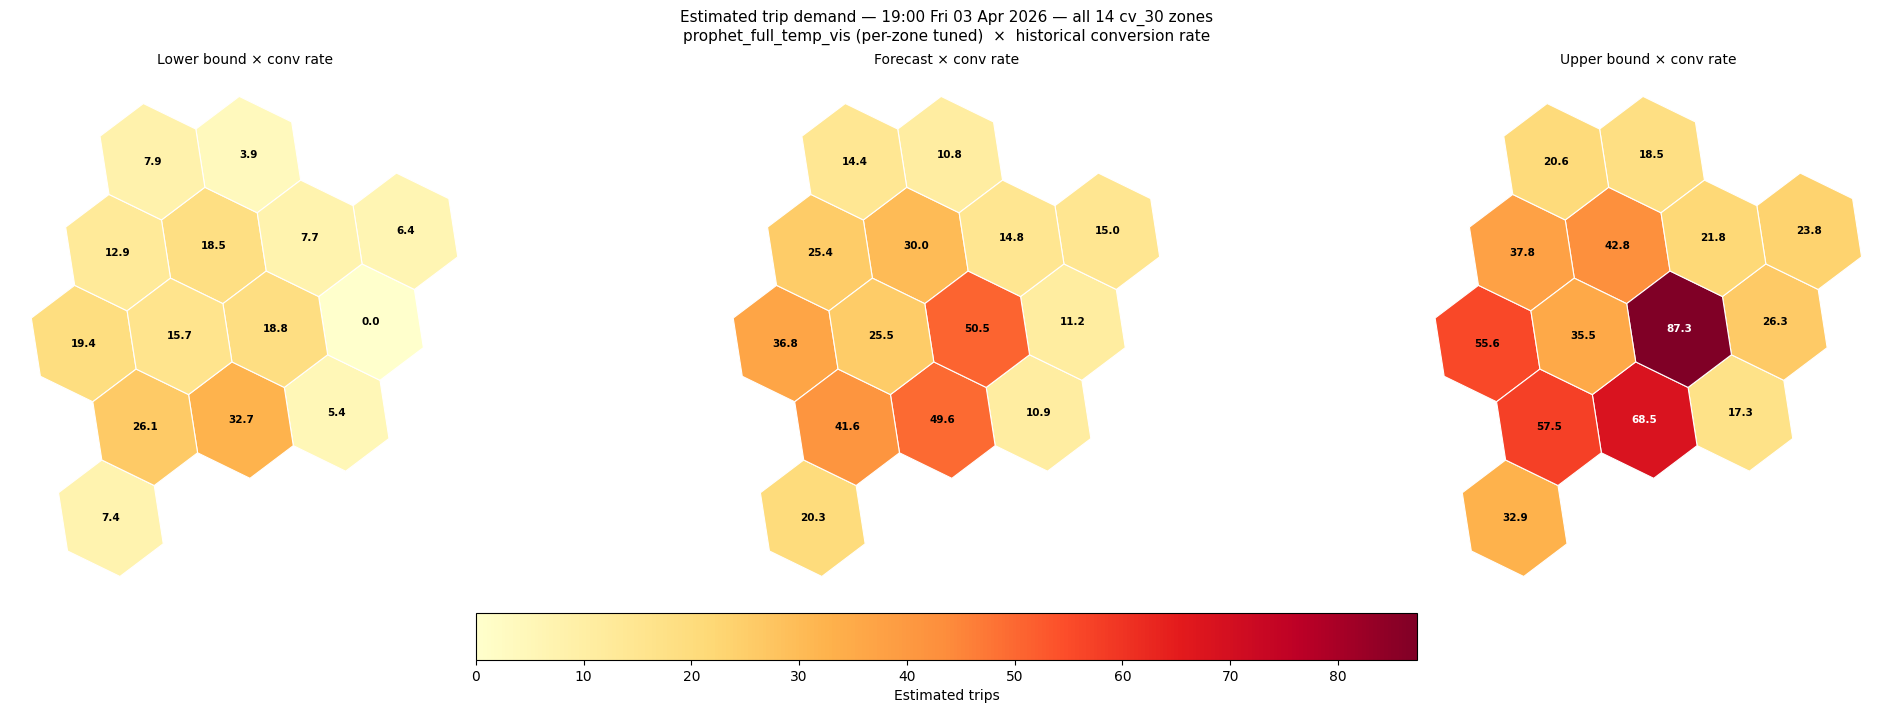

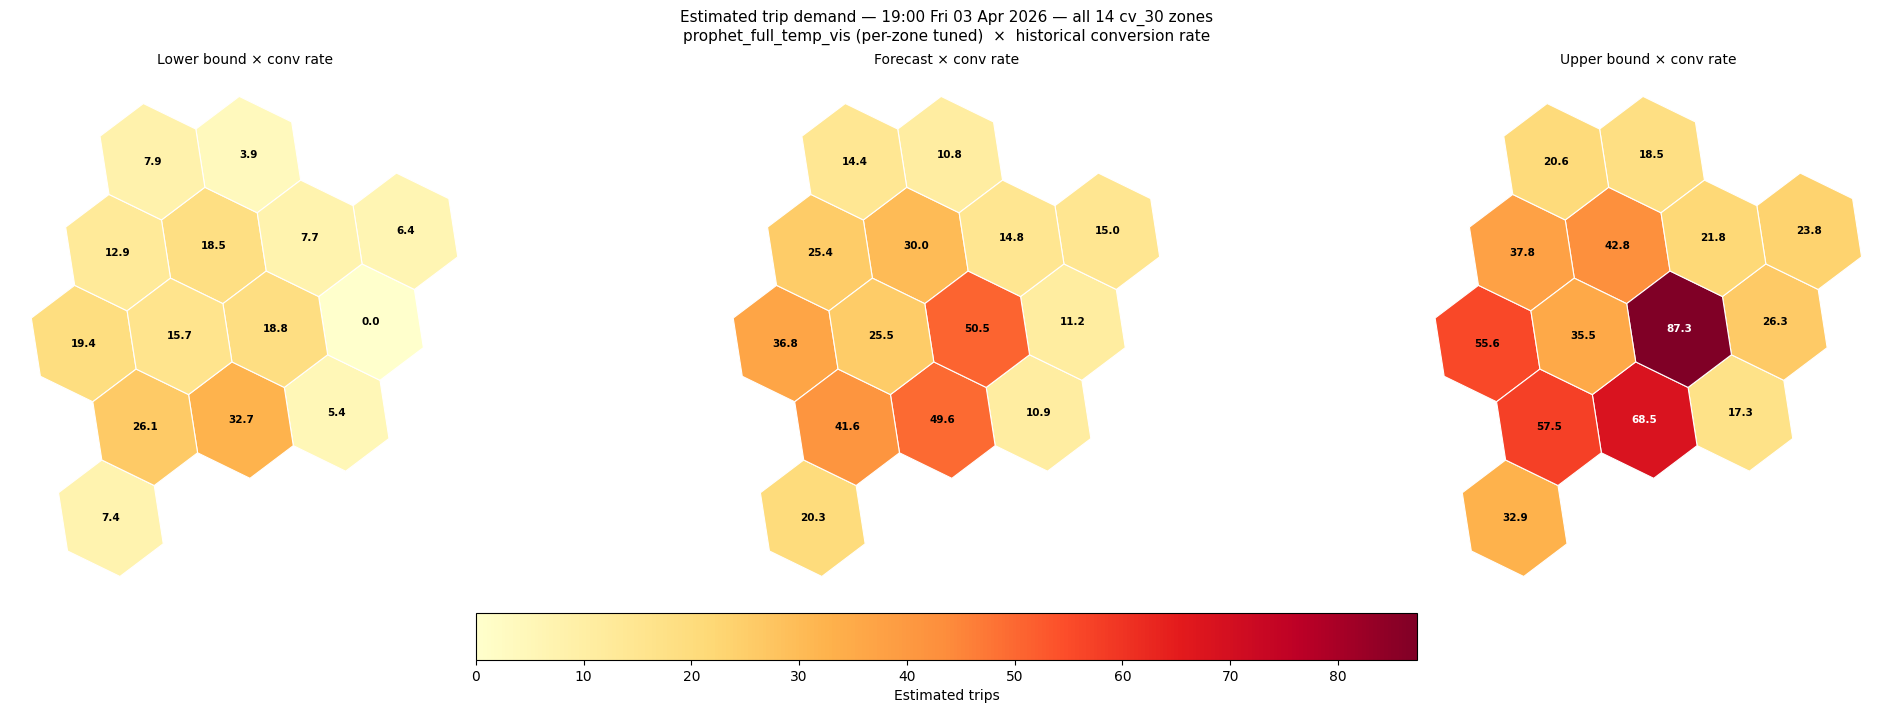

In [22]:
# ── H3 demand maps — 19:00 Fri 03 Apr 2026 (all 14 zones) ────────────────────
APR3_TS = pd.Timestamp("2026-04-03 19:00:00", tz="UTC")

map_apr = (
    apr_forecast_df[apr_forecast_df["ds"] == APR3_TS]
    [["zone", "yhat_lower", "yhat", "yhat_upper",
      "conv_rate", "trips_lower", "trips_pred", "trips_upper"]]
    .reset_index(drop=True)
)
print(f"Zones at {APR3_TS}: {len(map_apr)}")

gdf_apr = h3_ids_to_geodataframe(map_apr)

scenario_cols   = ["trips_lower", "trips_pred", "trips_upper"]
scenario_labels = ["Lower bound × conv rate", "Forecast × conv rate", "Upper bound × conv rate"]

plot_h3_demand_maps(
    gdf_apr, scenario_cols, scenario_labels,
    "Estimated trip demand — 19:00 Fri 03 Apr 2026 — all 14 cv_30 zones\n"
    "prophet_full_temp_vis (per-zone tuned)  ×  historical conversion rate",
)

## 9. April forecast plot — best zone

Apr 1–7 demand forecast for the three highest-volume cv_30 zones (tuned `prophet_full_temp_vis`).  
Shaded band = 95% credible interval; line = predicted quote demand (`yhat`).

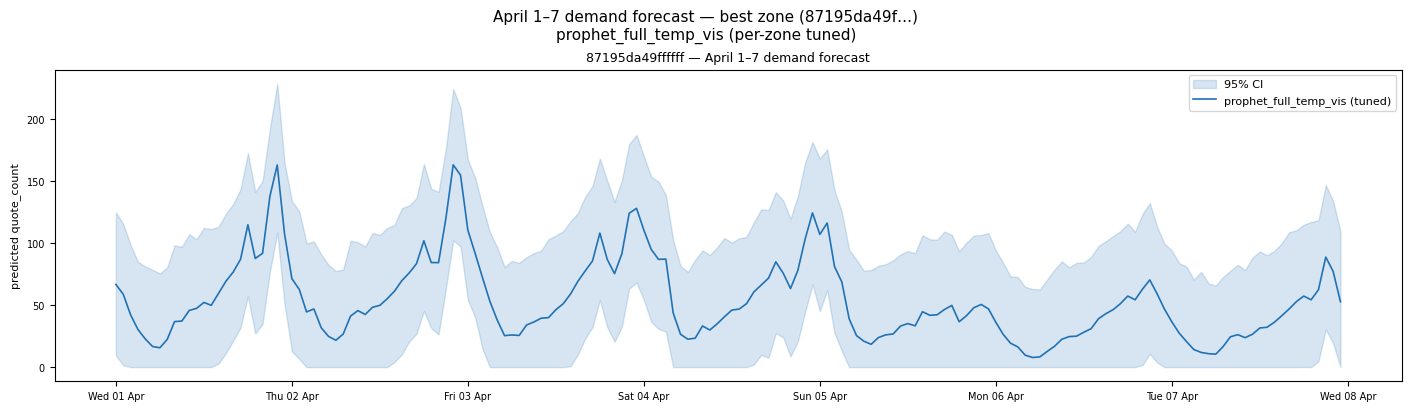

In [23]:
sub = (
    apr_forecast_df[apr_forecast_df["zone"] == best_zone]
    .sort_values("ds")
)

fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
ax.fill_between(sub["ds"], sub["yhat_lower"].clip(0), sub["yhat_upper"],
                color="#2171b5", alpha=0.18, label="95% CI")
ax.plot(sub["ds"], sub["yhat"],
        color="#2171b5", linewidth=1.2, label="prophet_full_temp_vis (tuned)")
ax.set_title(f"{best_zone} — April 1–7 demand forecast", fontsize=9)
ax.set_ylabel("predicted quote_count", fontsize=8)
ax.tick_params(labelsize=7)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
ax.legend(fontsize=8, loc="upper right")
fig.suptitle(
    f"April 1–7 demand forecast — best zone ({best_zone[:10]}…)\n"
    "prophet_full_temp_vis (per-zone tuned)",
    fontsize=11
)
plt.show()

## 10. Save forecasts

Write the April demand forecast to `demand_forecast_apr2026.parquet` via `save_demand_forecast()`.  

**Output schema** (columns sorted by zone → ds):

| Column | Description |
|---|---|
| `ds` | Forecast timestamp (UTC) |
| `zone` | H3 cell identifier |
| `yhat_lower` | 95% CI lower bound on quote demand |
| `yhat` | Predicted quote demand |
| `yhat_upper` | 95% CI upper bound on quote demand |
| `conv_rate` | Historical conversion rate for that (hour × day-of-week) |
| `trips_lower` | `yhat_lower × conv_rate` |
| `trips_pred` | `yhat × conv_rate` |
| `trips_upper` | `yhat_upper × conv_rate` |

In [ ]:
saved = save_demand_forecast(apr_forecast_df, OUT_PATH)
